File saved: comparison_clean.pdf


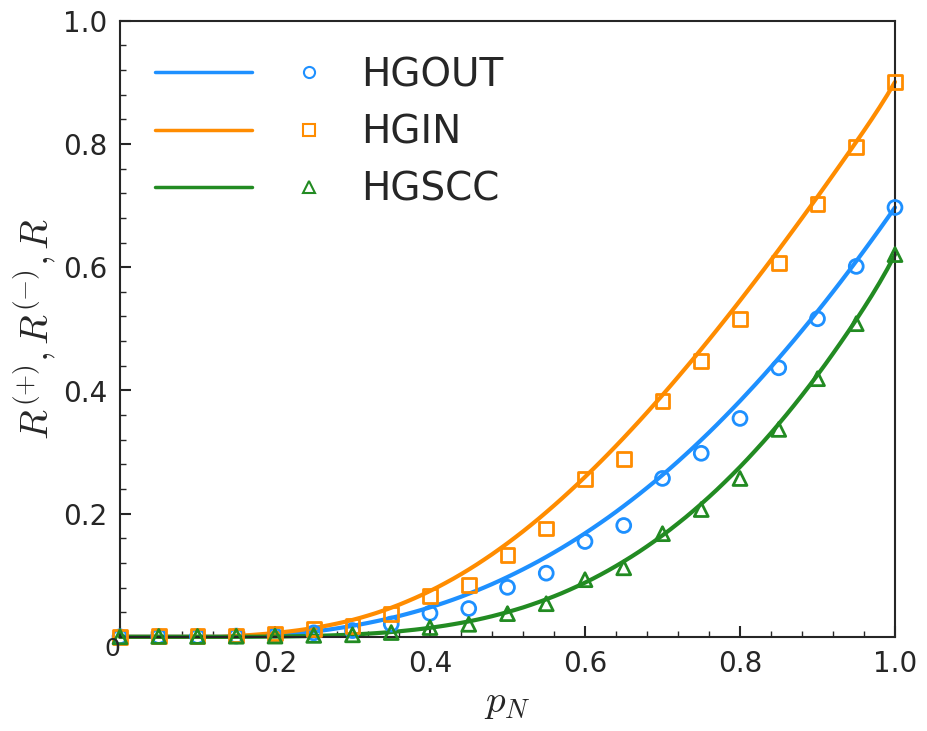

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoMinorLocator
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-white')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 18
plt.rcParams['axes.labelsize'] = 28
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 26
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.minor.width'] = 1.0
plt.rcParams['ytick.minor.width'] = 1.0

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})

filename = 'percolation.txt'

try:
    df = pd.read_csv(filename, delimiter=',')

    p_values_to_show = np.arange(0.0, 1.01, 0.05)
    df_scatter = df[df['node_survival'].round(2).isin(p_values_to_show.round(2))]

    fig, ax = plt.subplots(figsize=(10, 8))

    ax.plot(df['node_survival'], df['mp_gout'], color='dodgerblue', linestyle='-', linewidth=3, zorder=2, clip_on=False)
    ax.plot(df['node_survival'], df['mp_gin'],  color='darkorange', linestyle='-', linewidth=3, zorder=2, clip_on=False)
    ax.plot(df['node_survival'], df['mp_gscc'], color='forestgreen', linestyle='-', linewidth=3, zorder=2, clip_on=False)

    ax.scatter(df_scatter['node_survival'], df_scatter['sim_gout'], facecolors='none', edgecolors='dodgerblue', marker='o', s=100, linewidth=2, zorder=3, clip_on=False)
    ax.scatter(df_scatter['node_survival'], df_scatter['sim_gin'],  facecolors='none', edgecolors='darkorange', marker='s', s=100, linewidth=2, zorder=3, clip_on=False)
    ax.scatter(df_scatter['node_survival'], df_scatter['sim_gscc'], facecolors='none', edgecolors='forestgreen', marker='^', s=100, linewidth=2, zorder=3, clip_on=False)

    ax.set_xlabel('$p_N$', fontstyle='italic')
    ax.set_ylabel(r'$R^{(+)}\mathrm{,}\,R^{(-)}\mathrm{,}\,R$')

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0, 1.0)
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xticklabels(['', '0.2', '0.4', '0.6', '0.8', '1.0'])
    ax.set_yticklabels(['', '0.2', '0.4', '0.6', '0.8', '1.0'])
    ax.text(0, 0, '0', horizontalalignment='right', verticalalignment='top', transform=ax.transAxes)

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.tick_params(which='major', direction='in', length=8)
    ax.tick_params(which='minor', direction='in', length=4)

    line_handles = [
        Line2D([0], [0], color='dodgerblue', lw=2.5),
        Line2D([0], [0], color='darkorange', lw=2.5),
        Line2D([0], [0], color='forestgreen', lw=2.5)
    ]
    marker_handles = [
        Line2D([0], [0], color='dodgerblue', marker='o', linestyle='None', markersize=8, markerfacecolor='none', markeredgewidth=1.5),
        Line2D([0], [0], color='darkorange', marker='s', linestyle='None', markersize=8, markerfacecolor='none', markeredgewidth=1.5),
        Line2D([0], [0], color='forestgreen', marker='^', linestyle='None', markersize=8, markerfacecolor='none', markeredgewidth=1.5)
    ]

    handles = [line_handles[0], line_handles[1], line_handles[2], marker_handles[0], marker_handles[1], marker_handles[2]]
    labels = ['', '', '', 'HGOUT', 'HGIN', 'HGSCC']

    ax.legend(handles, labels,
              loc='upper left',
              ncol=2,
              frameon=False,
              fontsize=28,
              handlelength=2.5,
              handletextpad=0.1,
              columnspacing=0.1)

    output_filename = 'comparison_clean.pdf'
    plt.savefig(output_filename, bbox_inches='tight')

    print(f"File saved: {output_filename}")

except Exception as e:
    print(f"Error: {e}")